# 🔹 Model Optimization Script

This file searches for the optimal configuration to build the best-performing model.


In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
import tensorflow as tf
from IPython.display import Audio

import torchaudio
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Model, Wav2Vec2Processor, Trainer, TrainingArguments, Wav2Vec2ForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import opensmile
from tqdm import tqdm
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')

c:\Users\41788\anaconda3\envs\audio_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 🔹 Dataset Loading
- Load all audio file paths and their corresponding labels from the dataset.
- Each subdirectory represents a different label (dog breed).
- Collect file paths and assign labels based on folder names.
- Store results in a DataFrame for further processing.

In [2]:
razza = "frenchPoodle"

dirRazza = razza[0].upper() + razza[1:]

folder_directory = f'D:\Scuola\TESI-2025\Mescalina2017_sorted\{dirRazza}\sounds'
seed = 1

paths = []
labels = []

for dirname, _, filenames in os.walk(folder_directory):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)
        paths.append(file_path)
        label = os.path.basename(dirname)
        labels.append(label)

df = pd.DataFrame({"audio_paths": paths, "labels": labels})
print(df.head())
print(df['labels'].value_counts())
print(f"\nTotale file: {len(df)}, razze: {df['labels'].nunique()}")

                                         audio_paths labels
0  D:\Scuola\TESI-2025\Mescalina2017_sorted\Frenc...  B-AGR
1  D:\Scuola\TESI-2025\Mescalina2017_sorted\Frenc...  B-AGR
2  D:\Scuola\TESI-2025\Mescalina2017_sorted\Frenc...  B-AGR
3  D:\Scuola\TESI-2025\Mescalina2017_sorted\Frenc...  B-AGR
4  D:\Scuola\TESI-2025\Mescalina2017_sorted\Frenc...  B-AGR
labels
B-NEU     940
B-AGR     620
B-OWN     197
W-NEG      91
G-NEG      87
B-ANX      86
B-PLY      39
G-POS      21
W-POS      18
B-HOM      14
B-FEAR      9
B-WLK       1
Name: count, dtype: int64

Totale file: 2123, razze: 12


# 🔹 Feature Extraction Utilities

- **`load_paths(file_path)`**  
  Reads a text file containing one audio file path per line and returns a list of cleaned paths.

- **`extract_lld_features(audio_path)`**  
  Extracts Low-Level Descriptors (LLDs) from an audio file using the `ComParE_2016` feature set provided by `openSMILE`.  
  Returns a NumPy array of extracted features.


In [1]:
def load_paths(file_path):
        with open(file_path) as f:
            return [line.strip() for line in f]
        
def extract_lld_features(audio_path):
    """Estrae LLD e applica padding se necessario"""
    smile = opensmile.Smile(
        feature_set=opensmile.FeatureSet.ComParE_2016,
        feature_level=opensmile.FeatureLevel.LowLevelDescriptors
    )
    features = smile.process_file(audio_path).values
    return features 

# 🔹 Experimental Training Loop for Varying MIN_FILES, Learning Rates, and Batch Sizes

This training loop systematically evaluates model performance under different dataset configurations and hyperparameters. The goal is to observe how varying the number of files per class (`MIN_FILES`), learning rate, and batch size impacts the model’s ability to classify dog barks.

## ✅ Setup

- **`min_files_range`**: Number of files per class varies from 20 to 100 in steps of 10.
- **Learning Rates**: `[0.01, 0.001, 0.0005]`
- **Batch Sizes**: `[8, 16, 32, 64]`
- **Fixed seed**: Ensures consistency of train/val/test splits across experiments.

## 🔁 For each combination of `MIN_FILES`, `learning_rate`, and `batch_size`:

### 📁 Data Filtering
- Count files per class and keep only classes with at least `MIN_FILES` examples.
- Sample exactly `MIN_FILES` files per valid label.
- Use predefined seed-based train/val/test splits from text files.
- Subset the filtered DataFrame accordingly.

### 🎧 Feature Extraction
- Extract Low-Level Descriptors (LLDs) for all audio files using `openSMILE`.
- Determine the maximum sequence length across all datasets.
- Pad or truncate sequences to match this maximum length.
- Record the number of features per timestep.

### 🎯 Preprocessing
- Encode class labels into integers using `LabelEncoder`.
- Normalize all features using the training set’s global mean and standard deviation.
- Reshape inputs for Conv1D: `(samples, max_len, n_features, 1)`.

### 🧠 Model Architecture
A simple 1D CNN:
- Conv1D → MaxPooling
- Conv1D → MaxPooling
- GlobalAveragePooling
- Dense softmax output layer (number of classes)

### 🛠️ Compilation
- Optimizer: Adam (with current `learning_rate`)
- Loss: Sparse categorical crossentropy
- Metric: Accuracy

### 🏋️ Training & Evaluation
- Train for 100 epochs using the current `batch_size`.
- Evaluate test accuracy and loss.
- Store:
  - Train/val accuracy and loss over epochs
  - Final test accuracy/loss
  - Labels used for the current setup

## 📊 Results
All outcomes are appended to a list of dictionaries (`results`) for later analysis, comparison, or visualization.


In [ ]:
min_files_range = range(20, 101, 10)
learning_rates = [0.01, 0.001, 0.0005]
batch_sizes = [8, 16, 32, 64]
seed = 1
seed_dir = os.path.join(f"split_lists/{razza}", f"seed_test")

used_labels = sorted(df['labels'].unique().tolist())
results = []


for MIN_FILES in min_files_range:
    for lr in learning_rates:
        for batch_size in batch_sizes:
            label_counts = df['labels'].value_counts()

            valid_labels = label_counts[label_counts >= MIN_FILES].index

            filtered_df = df[df['labels'].isin(valid_labels)]

            df_subset = filtered_df.groupby('labels').head(MIN_FILES).reset_index(drop=True)

            used_labels = sorted(df_subset['labels'].unique().tolist())

            train_paths = load_paths(os.path.join(seed_dir, "train.txt"))
            val_paths = load_paths(os.path.join(seed_dir, "val.txt"))
            test_paths = load_paths(os.path.join(seed_dir, "test.txt"))

            train_df = df_subset[df_subset['audio_paths'].isin(train_paths)].reset_index(drop=True)
            val_df = df_subset[df_subset['audio_paths'].isin(val_paths)].reset_index(drop=True)
            test_df = df_subset[df_subset['audio_paths'].isin(test_paths)].reset_index(drop=True)

            print(f"[✓] Split caricato da seed test")
            print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

            print("Estrazione feature LLD...")
            train_sequences = [extract_lld_features(path) for path in tqdm(train_df['audio_paths'])]
            val_sequences = [extract_lld_features(path) for path in tqdm(val_df['audio_paths'])]
            test_sequences = [extract_lld_features(path) for path in tqdm(test_df['audio_paths'])]

            max_len = max(seq.shape[0] for seq in train_sequences + val_sequences + test_sequences)
            n_features = train_sequences[0].shape[1]  

            X_train = pad_sequences(train_sequences, maxlen=max_len, dtype='float32', padding='post', truncating='post')
            X_val = pad_sequences(val_sequences, maxlen=max_len, dtype='float32', padding='post', truncating='post')
            X_test = pad_sequences(test_sequences, maxlen=max_len, dtype='float32', padding='post', truncating='post')

            label_encoder = LabelEncoder()
            y_train = label_encoder.fit_transform(train_df['labels'])

            y_val = label_encoder.transform(val_df['labels'])
            y_test = label_encoder.transform(test_df['labels'])

            mean = X_train.mean(axis=(0,1))
            std = X_train.std(axis=(0,1))    

            X_train = (X_train - mean) / (std + 1e-8)
            X_val = (X_val - mean) / (std + 1e-8)
            X_test = (X_test - mean) / (std + 1e-8)

            # 5. Reshape finale per CNN
            X_train = X_train.reshape(-1, max_len, n_features, 1)
            X_val = X_val.reshape(-1, max_len, n_features, 1)
            X_test = X_test.reshape(-1, max_len, n_features, 1)

            model = models.Sequential([
            layers.Input(shape=(2225, 65)),
            layers.Conv1D(64, 3, activation='relu', padding='same'),
            layers.MaxPooling1D(2),
            layers.Conv1D(128, 3, activation='relu', padding='same'),
            layers.MaxPooling1D(2),
            layers.GlobalAveragePooling1D(),
            layers.Dense(len(np.unique(y_train)), activation='softmax')
            ])


            model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

            print(f"\nTraining con seed {seed}, MIN_FILES={MIN_FILES}, LR={lr}, BATCH={batch_size}...")

            history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=batch_size,
            )

            test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
            print(f"Seed {seed} - MIN_FILES={MIN_FILES} - LR={lr} - BATCH={batch_size} - Test Accuracy: {test_acc:.4f}")


            results.append({
                'MIN_FILES': MIN_FILES,
                'learning_rate': lr,
                'batch_size': batch_size,
                'train_acc': history.history['accuracy'],
                'val_acc': history.history['val_accuracy'],
                'train_loss': history.history['loss'],
                'val_loss': history.history['val_loss'],
                'test_acc': test_acc,
                'test_loss': test_loss,
                'labels_used': used_labels
            })




[✓] Split caricato da seed test
Train: 85, Val: 18, Test: 17
Estrazione feature LLD...


100%|██████████| 17/17 [00:01<00:00,  9.96it/s]



Training con seed 1, MIN_FILES=20, LR=0.01, BATCH=8...
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.1672 - loss: 2.6066 - val_accuracy: 0.2222 - val_loss: 1.7965
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2571 - loss: 1.7417 - val_accuracy: 0.2222 - val_loss: 1.6809
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4770 - loss: 1.2433 - val_accuracy: 0.5556 - val_loss: 1.1929
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6253 - loss: 1.0444 - val_accuracy: 0.5000 - val_loss: 1.0308
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6129 - loss: 0.8107 - val_accuracy: 0.5000 - val_loss: 0.8913
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7188 - loss: 0.7344 - val_accuracy: 0.5556 - val_loss: 0.7632
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7511 - loss: 0.6093 - val_accuracy: 0.6111 - val_loss: 0.7276
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/s

100%|██████████| 17/17 [00:01<00:00, 10.68it/s]



Training con seed 1, MIN_FILES=20, LR=0.01, BATCH=16...
Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.1094 - loss: 3.0696 - val_accuracy: 0.1667 - val_loss: 1.7820
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1803 - loss: 1.8195 - val_accuracy: 0.3889 - val_loss: 1.6828
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4854 - loss: 1.4986 - val_accuracy: 0.3333 - val_loss: 1.4938
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4496 - loss: 1.3130 - val_accuracy: 0.3889 - val_loss: 1.3246
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5938 - loss: 1.0684 - val_accuracy: 0.6111 - val_loss: 1.0700
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6398 - loss: 0.9439 - val_accuracy: 0.6111 - val_loss: 0.8848
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6381 - loss: 0.7273 - val_accuracy: 0.5556 - val_loss: 0.9014
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy:

...


Training con seed 1, MIN_FILES=100, LR=0.0005, BATCH=32...
Epoch 1/100


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.3906 - loss: 1.0955 - val_accuracy: 0.4091 - val_loss: 1.0911
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3926 - loss: 1.0646 - val_accuracy: 0.2273 - val_loss: 1.0984
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5453 - loss: 1.0208 - val_accuracy: 0.5455 - val_loss: 1.0959
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6226 - loss: 1.0014 - val_accuracy: 0.3636 - val_loss: 1.0731
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4204 - loss: 1.0162 - val_accuracy: 0.4545 - val_loss: 1.0532
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6011 - loss: 0.9818 - val_accuracy: 0.6364 - val_loss: 1.0572
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6729 - loss: 0.9585 - val_accuracy: 0.5455 - val_loss: 1.0666
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6424 - loss: 0.9326 - val_accuracy: 0.6364 - val_loss: 1.0293
Epo

100%|██████████| 23/23 [00:02<00:00, 10.22it/s]


Training con seed 1, MIN_FILES=100, LR=0.0005, BATCH=64...
Epoch 1/100


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 0.3633 - loss: 1.0918 - val_accuracy: 0.5000 - val_loss: 1.0794
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.4882 - loss: 1.0633 - val_accuracy: 0.5909 - val_loss: 1.0834
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5916 - loss: 1.0534 - val_accuracy: 0.5000 - val_loss: 1.0774
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5193 - loss: 1.0349 - val_accuracy: 0.4545 - val_loss: 1.0720
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5211 - loss: 1.0159 - val_accuracy: 0.4091 - val_loss: 1.0655
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5644 - loss: 0.9995 - val_accuracy: 0.6364 - val_loss: 1.0579
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7042 - loss: 0.9784 - val_accuracy: 0.8182 - val_loss: 1.0512
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.7400 - loss: 0.9643 - val_accuracy: 0.7273 - val_loss: 1.0424
E

# 🔹 Analysis and Visualization of Experimental Results

This script processes and visualizes training results from multiple experiments performed on different `MIN_FILES` thresholds and hyperparameter combinations. It saves plots and selects the best-performing configuration for each threshold.

## 📂 Directory Setup

- `base_dir`: Output folder where all plots and summary files will be saved, structured by `razza` and `MIN_FILES`.

## 📊 Grouping and Visualization by MIN_FILES

For each group of experiments sharing the same `MIN_FILES` value:

### 1. 📈 Training and Validation Performance

- Creates a 2x2 subplot figure with:
  - Top left: Training Accuracy over epochs
  - Top right: Validation Accuracy
  - Bottom left: Training Loss
  - Bottom right: Validation Loss
- Each curve corresponds to a specific combination of:
  - Learning rate
  - Batch size
- Saves the plot as `training_validation.png` under the folder named after `MIN_FILES`.

### 2. 🧪 Test Accuracy and Loss

- Creates a bar chart with:
  - Left: Test Accuracy for each experiment
  - Right: Test Loss for each experiment
- Uses short readable labels like `LR 1e-03 | BS 32`.
- Saves the plot as `test_results.png`.

### 3. 🏆 Best Configuration Selection

- For each `MIN_FILES` group, finds the experiment with the **highest test accuracy**.
- Stores its:
  - Learning rate
  - Batch size
  - Test accuracy
  - Test loss
- Appends this data to the `best_solutions` list.

## 💾 Saving Best Results

- Exports the best configurations for each `MIN_FILES` value as a JSON file:
  - Path: `best_solutions.json`

## 📌 Summary Visualization

- Creates a summary bar chart showing the **best test accuracy** for each `MIN_FILES` value.
- Annotates each bar with the accuracy percentage.
- Saves the chart as `best_accuracy_summary.png`.

## ✅ Outputs

Each `MIN_FILES` folder contains:
- `training_validation.png`
- `test_results.png`

The base directory contains:
- `best_solutions.json`
- `best_accuracy_summary.png`


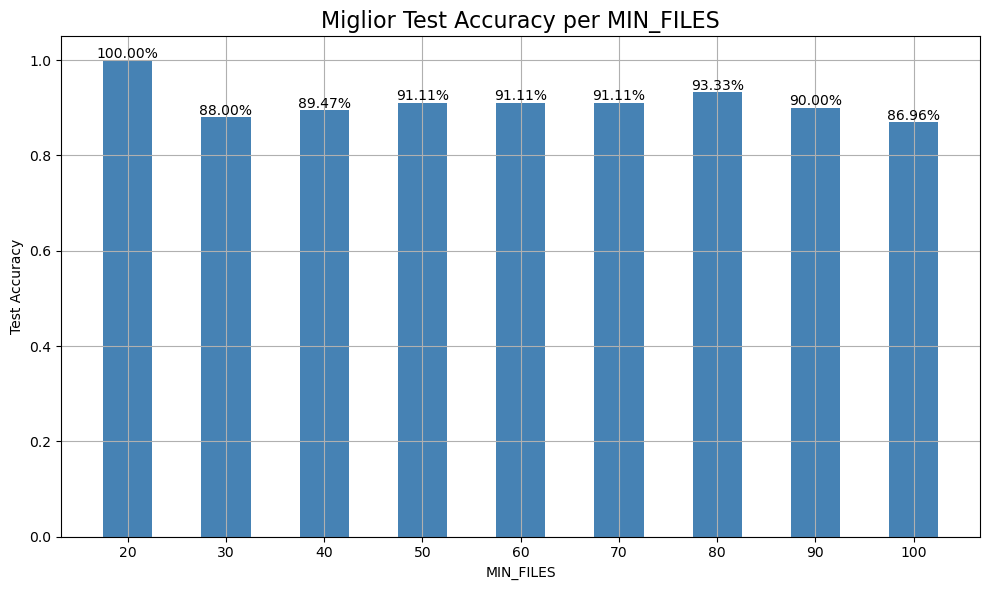

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import os
import json

base_dir = f"D:\Scuola\TESI-2025\Results\Context\{razza}"

grouped_results = defaultdict(list)
for entry in results:
    grouped_results[entry['MIN_FILES']].append(entry)


best_solutions = []

for min_files, group in grouped_results.items():
    folder_path = os.path.join(base_dir, str(min_files))
    os.makedirs(folder_path, exist_ok=True)

    labels = [
        f"LR {entry['learning_rate']:.0e} | BS {entry['batch_size']}"
        for entry in group
    ]

    # ---------- FIGURA 1: Training / Validation ---------- #
    fig1, axs1 = plt.subplots(2, 2, figsize=(18, 12))
    fig1.suptitle(f"Training e Validation - MIN_FILES = {min_files} | {razza}", fontsize=18)
    fig1.subplots_adjust(hspace=0.4, wspace=0.3)

    best_entry = None
    best_test_acc = -np.inf

    for entry, label in zip(group, labels):
        epochs = range(1, len(entry['train_acc']) + 1)

        axs1[0, 0].plot(epochs, entry['train_acc'], label=label)
        axs1[0, 1].plot(epochs, entry['val_acc'], label=label)
        axs1[1, 0].plot(epochs, entry['train_loss'], label=label)
        axs1[1, 1].plot(epochs, entry['val_loss'], label=label)

        if entry['test_acc'] > best_test_acc:
            best_test_acc = entry['test_acc']
            best_entry = entry

    for ax in axs1.flat:
        ax.set_xlabel('Epochs')
        ax.grid(True)
        ax.legend(fontsize='small')

    axs1[0, 0].set_title('Train Accuracy')
    axs1[0, 1].set_title('Validation Accuracy')
    axs1[1, 0].set_title('Train Loss')
    axs1[1, 1].set_title('Validation Loss')
    axs1[0, 0].set_ylabel('Accuracy')
    axs1[0, 1].set_ylabel('Accuracy')
    axs1[1, 0].set_ylabel('Loss')
    axs1[1, 1].set_ylabel('Loss')

    fig1.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig1.savefig(os.path.join(folder_path, "training_validation.png"))
    plt.close(fig1)

    # ---------- FIGURA 2: Test Accuracy / Loss ---------- #
    test_acc_list = [entry['test_acc'] for entry in group]
    test_loss_list = [entry['test_loss'] for entry in group]

    fig2, axs2 = plt.subplots(1, 2, figsize=(18, 6))
    fig2.suptitle(f"Test Results - MIN_FILES = {min_files} | {razza}", fontsize=18)
    fig2.subplots_adjust(wspace=0.3)

    x = np.arange(len(group))
    bar_width = 0.6

    axs2[0].bar(x, test_acc_list, width=bar_width, color='tab:green')
    axs2[1].bar(x, test_loss_list, width=bar_width, color='tab:red')

    axs2[0].set_title('Test Accuracy')
    axs2[1].set_title('Test Loss')
    axs2[0].set_ylabel('Accuracy')
    axs2[1].set_ylabel('Loss')

    axs2[0].set_xticks(x)
    axs2[1].set_xticks(x)
    axs2[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    axs2[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=9)

    axs2[0].grid(True)
    axs2[1].grid(True)

    fig2.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig2.savefig(os.path.join(folder_path, "test_results.png"))
    plt.close(fig2)

    best_solutions.append({
        'MIN_FILES': min_files,
        'learning_rate': best_entry['learning_rate'],
        'batch_size': best_entry['batch_size'],
        'test_acc': best_entry['test_acc'],
        'test_loss': best_entry['test_loss']
    })

# ---------- SALVATAGGIO JSON risultati migliori ---------- #
with open(os.path.join(base_dir, "best_solutions.json"), "w") as f:
    json.dump(best_solutions, f, indent=2)

# ---------- GRAFICO RIASSUNTIVO ---------- #
min_files_list = [entry['MIN_FILES'] for entry in best_solutions]
test_acc_best = [entry['test_acc'] for entry in best_solutions]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(min_files_list, test_acc_best, color='steelblue', width=5)

ax.set_title("Miglior Test Accuracy per MIN_FILES", fontsize=16)
ax.set_xlabel("MIN_FILES")
ax.set_ylabel("Test Accuracy")
ax.grid(True)
ax.set_xticks(min_files_list)

for i, acc in enumerate(test_acc_best):
    ax.text(min_files_list[i], acc + 0.005, f"{acc:.2%}", ha='center', fontsize=10)

plt.tight_layout()
fig.savefig(os.path.join(base_dir, "best_accuracy_summary.png"))
plt.show()


# 🔹 Label Presence Heatmap per MIN_FILES

This script generates a heatmap showing which labels (classes) were included in each experiment based on the `MIN_FILES` threshold.

## 🧮 Logic Overview

- Extracts:
  - All unique `MIN_FILES` values used across experiments.
  - All unique labels encountered.
- Initializes a DataFrame where:
  - Rows represent individual labels.
  - Columns represent `MIN_FILES` values.
  - Cell value = 1 if the label was present for that threshold, 0 otherwise.

## 🔥 Heatmap Generation

- Uses `seaborn.heatmap()` to visualize the matrix:
  - Green color indicates the label was included for the corresponding `MIN_FILES`.
  - Labels not included are shown in white.
  - Gray gridlines separate rows and columns for clarity.


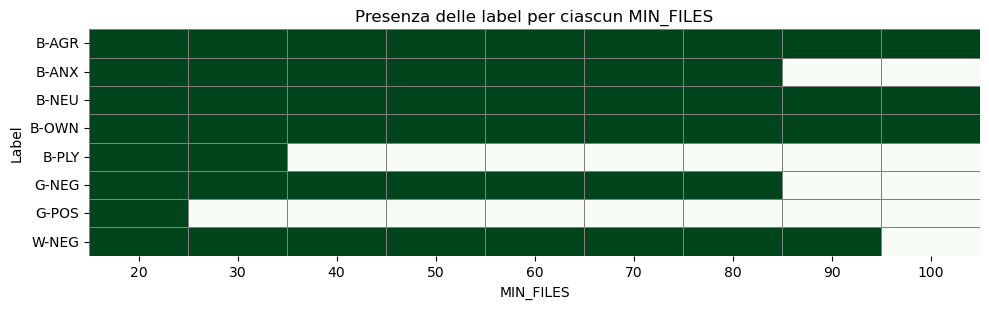

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

unique_min = sorted(set(entry['MIN_FILES'] for entry in results))
all_labels = sorted({label for entry in results for label in entry['labels_used']})

heatmap_data = pd.DataFrame(0, index=all_labels, columns=unique_min)

for entry in results:
    min_f = entry['MIN_FILES']
    for label in entry['labels_used']:
        heatmap_data.at[label, min_f] = 1

# Plot heatmap
plt.figure(figsize=(10, len(all_labels)*0.4))
sns.heatmap(heatmap_data, cmap="Greens", cbar=False, linewidths=0.5, linecolor='gray')
plt.title("Presenza delle label per ciascun MIN_FILES")
plt.xlabel("MIN_FILES")
plt.ylabel("Label")
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "label_presence_heatmap.png"), dpi=300)
plt.show()
